# STalign parity: `starmap-allen3Datlas-alignment.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/starmap-allen3Datlas-alignment.ipynb).

Status: `compared`. This notebook fits a 3D volume to a 2D section. The two sides are *expected* to differ numerically here, unlike every 2D notebook above: upstream's 3D regularisation energy transforms two of the three spatial axes (`dim=(1,2)`, STalign.py:1504) while smoothing that same energy's gradient over all three (`dim=(1,2,3)`, :1527), so it descends on a different objective than the one it reports. Squidpy uses every spatial axis in both places. The divergence below measures that deliberate choice -- see `docs/STALIGN_DIVERGENCES.md` row D11 -- and is not a port defect. Its cell [6] also reads the STARmap table through an absolute path on the notebook author's own machine (`/home/manju/Documents/...`), the only such path in the pinned notebook set; the replay rewrites the leading directories to the `../starmap_data/` convention the other notebooks use. Same file, same bytes.


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 0.010926335065040163,
  "AI relative L2": 0.9528721908467963,
  "Inorm relative L2": 0.0,
  "Ishow_source relative L2": 0.4831306763533353,
  "Ishow_target relative L2": 0.0,
  "It relative L2": 0.0,
  "Jnorm relative L2": 0.0,
  "Jt relative L2": 0.0,
  "L relative L2": 0.0,
  "Li relative L2": 0.0,
  "W relative L2": 0.0,
  "XA relative L2": 0.0,
  "X_ relative L2": 0.0,
  "Xs relative L2": 0.03276453093002183,
  "Y_ relative L2": 0.0,
  "extent relative L2": 0.0,
  "extentA relative L2": 0.0,
  "scale_atlas relative L2": 0.0,
  "v relative L2": 0.8787422112532637,
  "vol relative L2": 0.0,
  "x relative L2": 0.14971832306926697,
  "y relative L2": 0.013841859235407131,
  "z relative L2": 0.006160431271017848
}

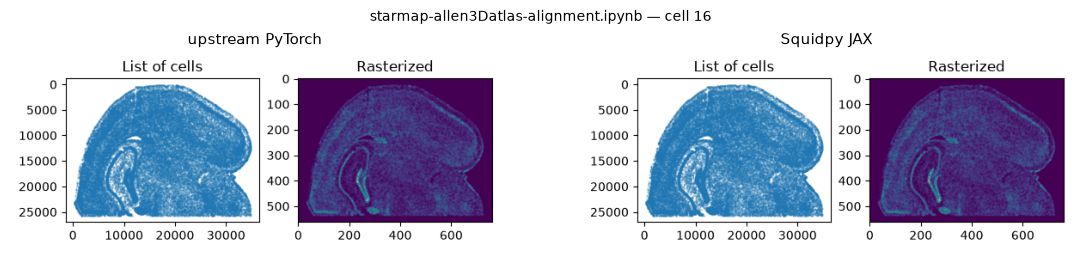

In [2]:
#Plot unrasterized/rasterized images
fig,ax = plt.subplots(1,2)
ax[0].scatter(x,y,s=0.5,alpha=0.25)
ax[0].invert_yaxis()
ax[0].set_title('List of cells')
ax[0].set_aspect('equal')

W = W[0]
extent = (X_[0],X_[-1],Y_[0],Y_[-1])    
ax[1].imshow(W,  origin='lower')    
ax[1].invert_yaxis()    
ax[1].set_title('Rasterized')

# save figure
#fig.canvas.draw()    
#fig.savefig(outname[:-4]+'_image.png')

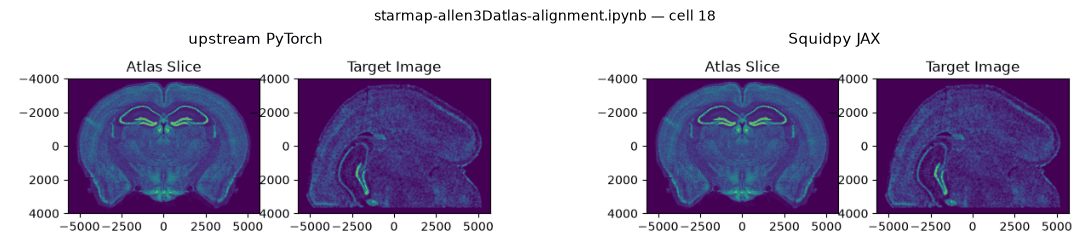

In [3]:
#find slice
#peruse through images in atlas
# Loading the atlas
slice = 140

vol,hdr = nrrd.read(imagefile)
A = vol    
vol,hdr = nrrd.read(labelfile)
L = vol

dxA = np.diag(hdr['space directions'])
nxA = A.shape
xA = [np.arange(n)*d - (n-1)*d/2.0 for n,d in zip(nxA,dxA)]
XA = np.meshgrid(*xA,indexing='ij')

fig,ax = plt.subplots(1,2)
extentA = STalign.extent_from_x(xA[1:])
ax[0].imshow(A[slice],extent=extentA)
ax[0].set_title('Atlas Slice')

ax[1].imshow(W,extent=extentA)
ax[1].set_title('Target Image')
fig.canvas.draw()    

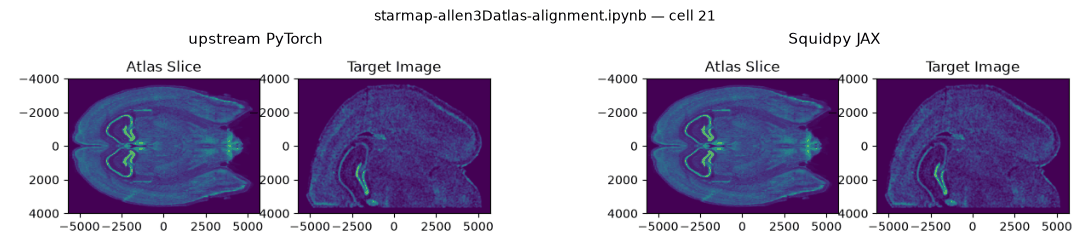

In [4]:
from scipy.ndimage import rotate

theta_deg = 90

fig,ax = plt.subplots(1,2)
extentA = STalign.extent_from_x(xA[1:])
ax[0].imshow(rotate(A[slice], angle=theta_deg),extent=extentA)
ax[0].set_title('Atlas Slice')

ax[1].imshow(W,extent=extentA)
ax[1].set_title('Target Image')
fig.canvas.draw()    

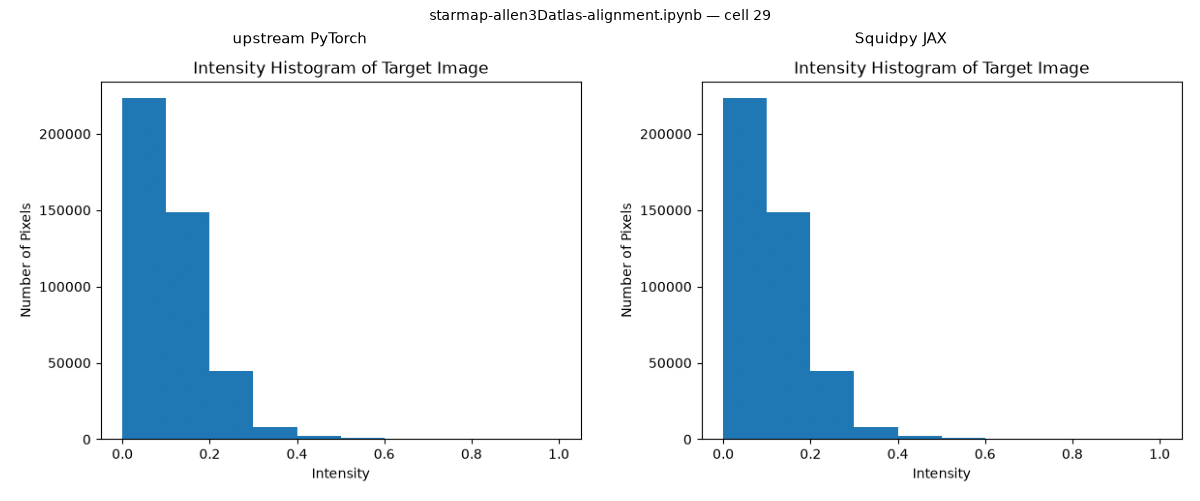

In [5]:
fig,ax = plt.subplots()
ax.hist(Jnorm.ravel())
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')
plt.title('Intensity Histogram of Target Image')

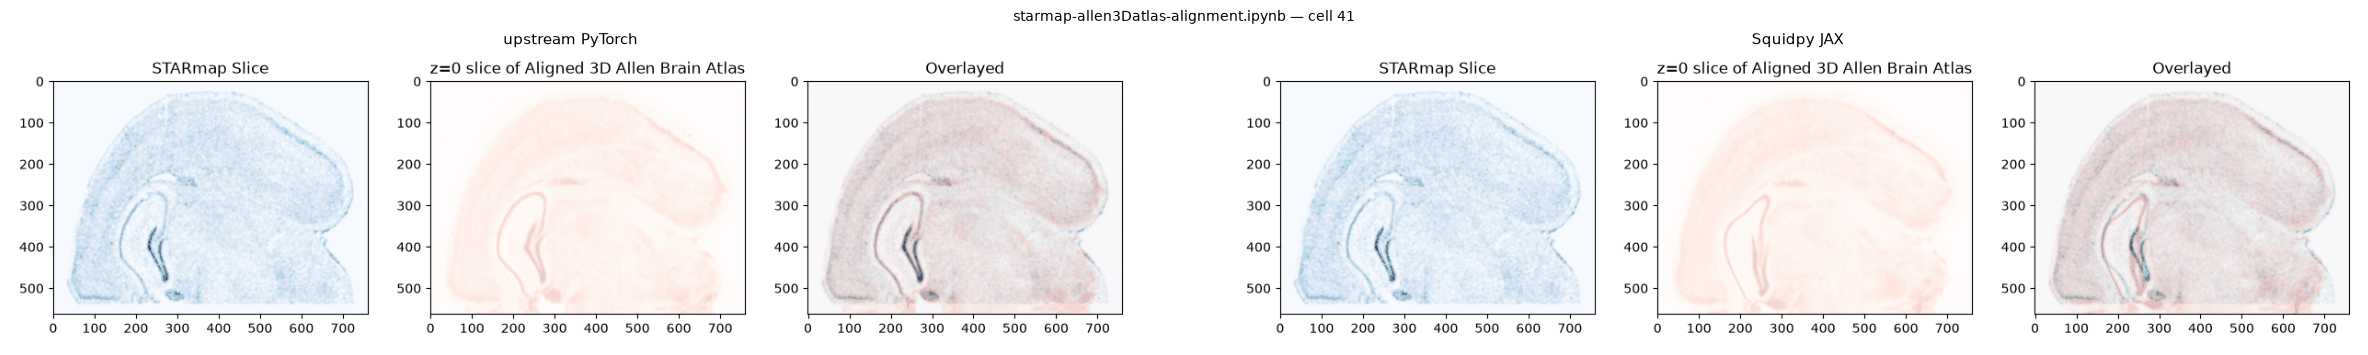

In [6]:
It = torch.tensor(I,device='cpu',dtype=torch.float64)
AI = STalign.interp3D(xI,It,Xs.permute(3,0,1,2),padding_mode="border")
Ishow_source = ((AI-torch.amin(AI,(1,2,3))[...,None,None])/(torch.amax(AI,(1,2,3))-torch.amin(AI,(1,2,3)))[...,None,None,None]).permute(1,2,3,0).clone().detach().cpu()
Jt = torch.tensor(J,device='cpu',dtype=torch.float64)
Ishow_target = Jt.permute(1,2,0).cpu()/torch.max(Jt).item()

import matplotlib as mpl
fig,ax = plt.subplots(1,3, figsize=(15,5))
ax0 = ax[0].imshow(Ishow_target, cmap = mpl.cm.Blues,alpha=0.9)
ax[0].set_title('STARmap Slice')
ax1 = ax[1].imshow(Ishow_source[0,:,:,0], cmap = mpl.cm.Reds,alpha=0.2)
ax[1].set_title('z=0 slice of Aligned 3D Allen Brain Atlas')
ax2 = ax[2].imshow(Ishow_target, cmap = mpl.cm.Blues,alpha=0.9)
ax2 = ax[2].imshow(Ishow_source[0,:,:,0], cmap = mpl.cm.Reds,alpha=0.3)
ax[2].set_title('Overlayed')

plt.show()

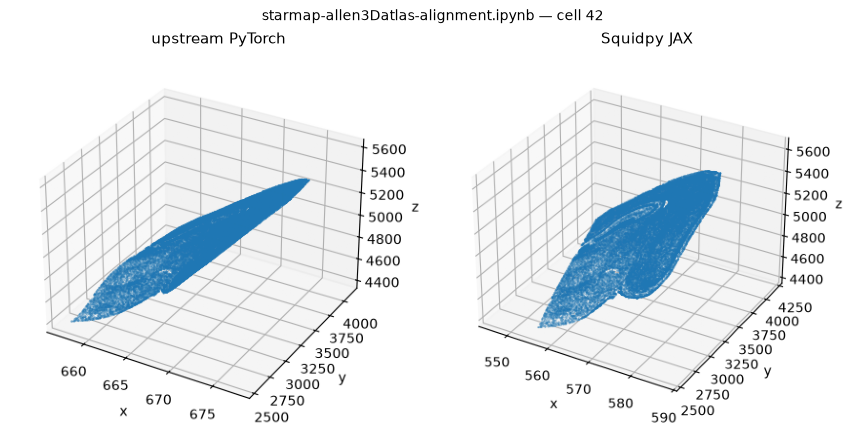

In [7]:
from mpl_toolkits import mplot3d

x=df['coord0']
y=-df['coord1']
z=df['coord2']

fig = plt.figure()
ax = plt.axes(projection='3d')

ax.scatter3D(x,y,z,s=0.05)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

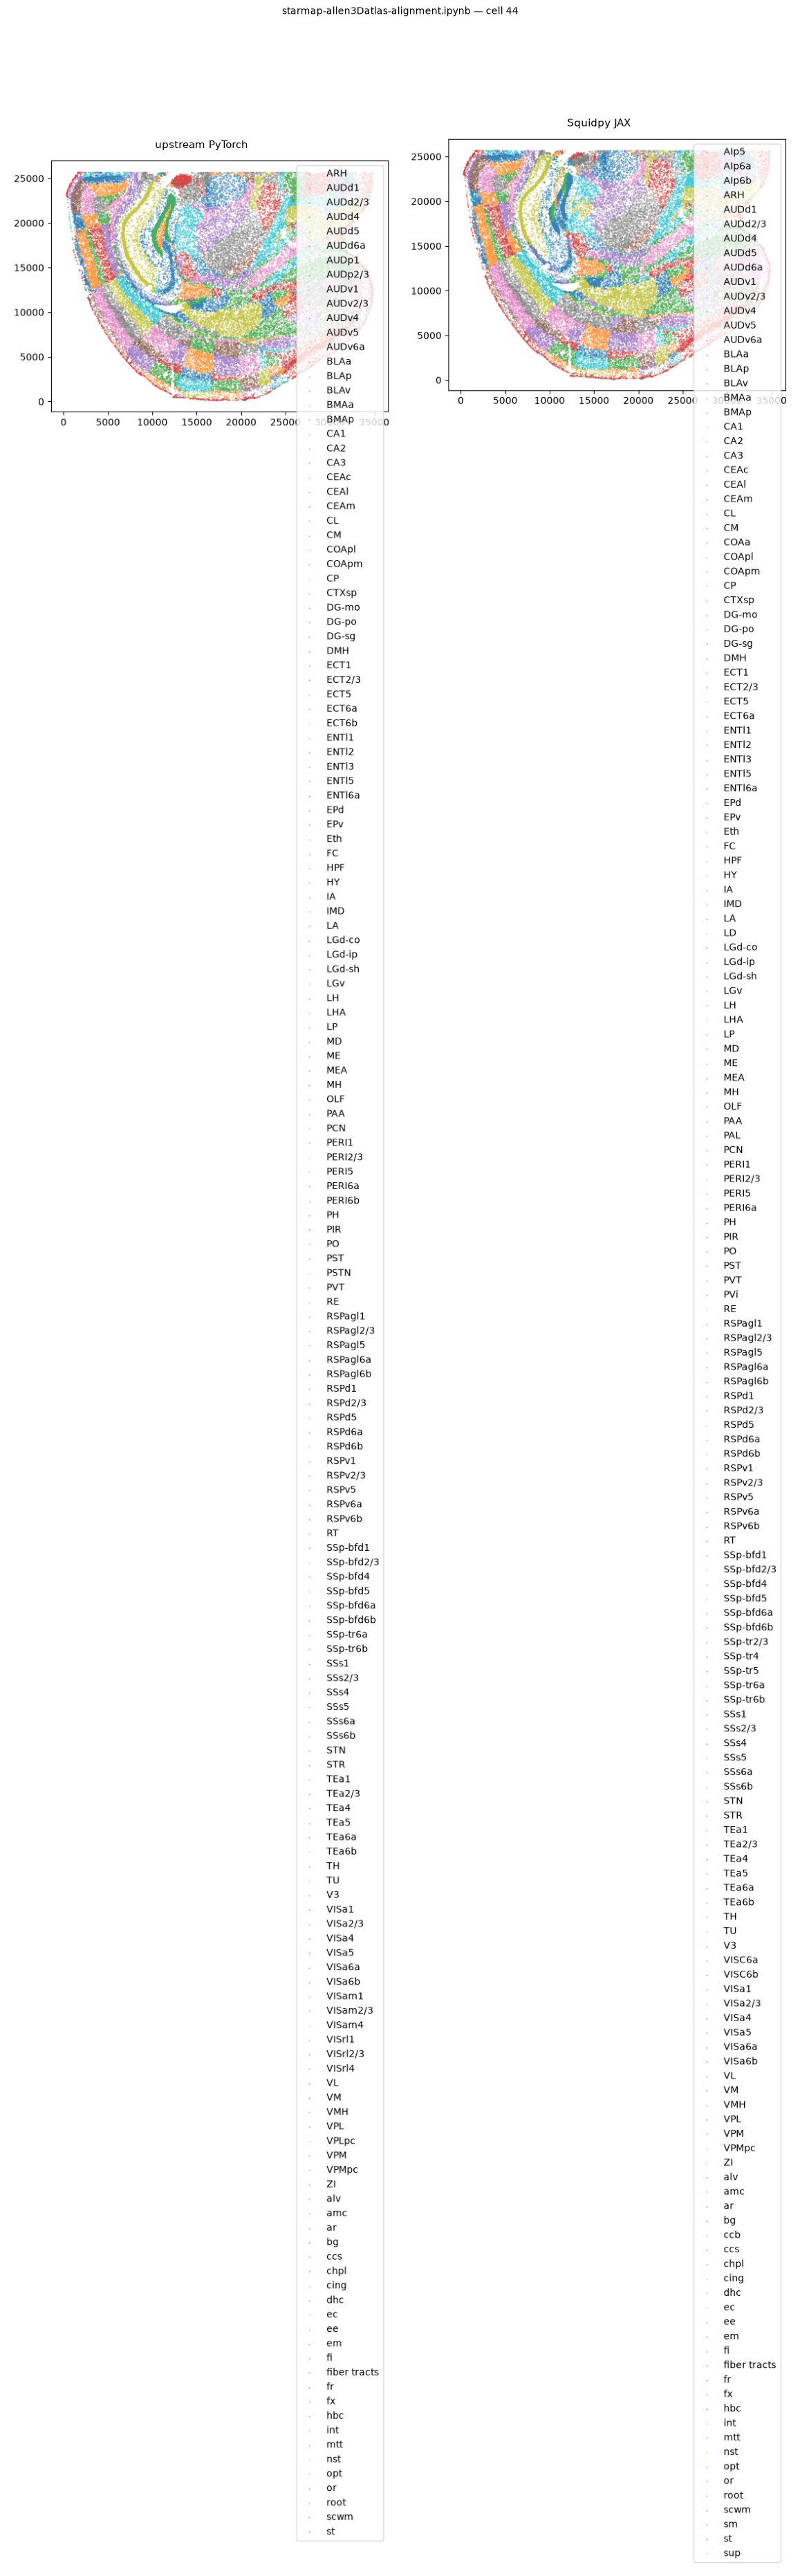

In [8]:
STalign.plot_brain_regions(df)

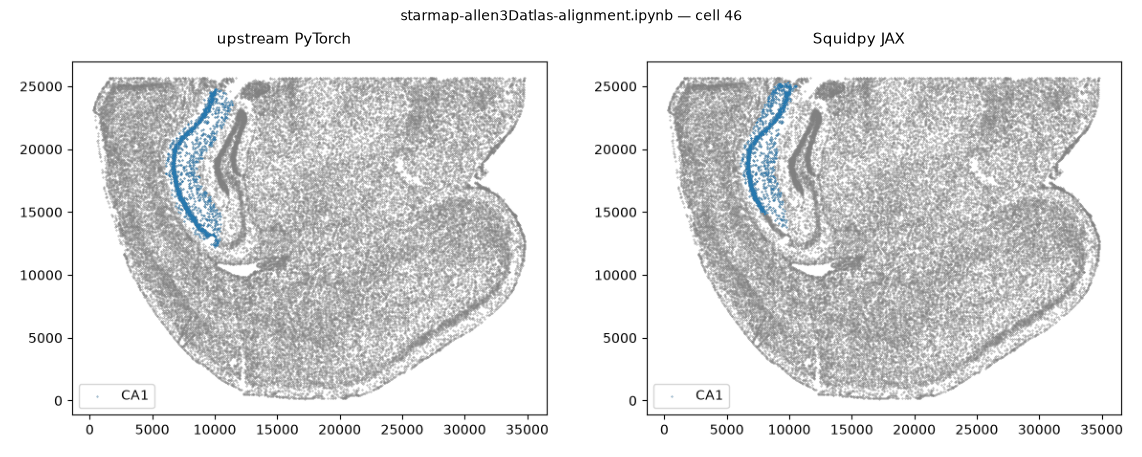

In [9]:
brain_regions = ['CA1']
STalign.plot_subset_brain_regions(df, brain_regions)